# LeetCode #1482: Minimum Number of Days to Make m Bouquets

https://leetcode.com/problems/minimum-number-of-days-to-make-m-bouquets/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (simulate each day)** | $O(D \cdot n)$ | $O(1)$ |
| **Optimal: Binary Search on Days ★** | $O(n \log D)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (simulate each day)
Try every day from 1 to max(bloomDay), counting consecutive bloomed flowers each time. Scans all $n$ flowers for up to $D = \max(\text{bloomDay})$ days — $O(D \cdot n)$, far too slow for $D \approx 10^9$.

### Optimal: Binary Search on Days ★
The feasibility function is monotone: if day $d$ works, so does every day $d' > d$. Binary search the answer space $[1, \max(\text{bloomDay})]$; for each candidate day, greedily count consecutive bloomed flowers to verify whether $m$ bouquets of size $k$ are available. Each check is $O(n)$; with $O(\log D)$ checks the total is $O(n \log D)$.

**Why this is better than Brute Force:** Binary search eliminates $D - \log D$ candidate days at no cost, reducing the day-iteration factor from linear to logarithmic.

**Constraints:**
* $1 \le \text{bloomDay.length} \le 10^5$
* $1 \le m, k \le 10^5$
* $1 \le \text{bloomDay}[i] \le 10^9$


## Solutions

### C#

In [ ]:
public int MinDays(int[] bloomDay, int m, int k) {
    // Impossible if not enough flowers even in total
    if ((long)m * k > bloomDay.Length) return -1;
    int lo = 1, hi = bloomDay.Max();
    while (lo < hi) {
        int mid = lo + (hi - lo) / 2;
        // Count bouquets available by day `mid`
        int bouquets = 0, consecutive = 0;
        foreach (int d in bloomDay) {
            if (d <= mid) {
                // Flower has bloomed — extend current run
                if (++consecutive == k) { bouquets++; consecutive = 0; }
            } else {
                // Gap resets the consecutive run
                consecutive = 0;
            }
        }
        // Shrink upper bound if feasible, else raise lower bound
        if (bouquets >= m) hi = mid;
        else lo = mid + 1;
    }
    return lo;
}


### Python

In [ ]:
def min_days(bloom_day: list[int], m: int, k: int) -> int:
    # Impossible if not enough flowers even in total
    if m * k > len(bloom_day):
        return -1
    lo, hi = 1, max(bloom_day)
    while lo < hi:
        mid = lo + (hi - lo) // 2
        # Count bouquets available by day `mid`
        bouquets = consecutive = 0
        for d in bloom_day:
            if d <= mid:
                # Flower has bloomed — extend current run
                consecutive += 1
                if consecutive == k:
                    bouquets += 1
                    consecutive = 0
            else:
                # Gap resets the consecutive run
                consecutive = 0
        # Shrink upper bound if feasible, else raise lower bound
        if bouquets >= m:
            hi = mid
        else:
            lo = mid + 1
    return lo


### Go

In [ ]:
func minDays(bloomDay []int, m int, k int) int {
    // Impossible if not enough flowers even in total
    if m*k > len(bloomDay) {
        return -1
    }
    lo, hi := 1, slices.Max(bloomDay)
    for lo < hi {
        mid := lo + (hi-lo)/2
        // Count bouquets available by day `mid`
        bouquets, consecutive := 0, 0
        for _, d := range bloomDay {
            if d <= mid {
                // Flower has bloomed — extend current run
                consecutive++
                if consecutive == k {
                    bouquets++
                    consecutive = 0
                }
            } else {
                // Gap resets the consecutive run
                consecutive = 0
            }
        }
        // Shrink upper bound if feasible, else raise lower bound
        if bouquets >= m {
            hi = mid
        } else {
            lo = mid + 1
        }
    }
    return lo
}


### Rust

In [ ]:
pub fn min_days(bloom_day: Vec<i32>, m: i32, k: i32) -> i32 {
    let n = bloom_day.len() as i64;
    // Impossible if not enough flowers even in total
    if m as i64 * k as i64 > n {
        return -1;
    }
    let (mut lo, mut hi) = (1i32, *bloom_day.iter().max().unwrap());
    while lo < hi {
        let mid = lo + (hi - lo) / 2;
        // Count bouquets available by day `mid`
        let (mut bouquets, mut consecutive) = (0i32, 0i32);
        for &d in &bloom_day {
            if d <= mid {
                // Flower has bloomed — extend current run
                consecutive += 1;
                if consecutive == k {
                    bouquets += 1;
                    consecutive = 0;
                }
            } else {
                // Gap resets the consecutive run
                consecutive = 0;
            }
        }
        // Shrink upper bound if feasible, else raise lower bound
        if bouquets >= m {
            hi = mid;
        } else {
            lo = mid + 1;
        }
    }
    lo
}


## Example Scenarios

**1. Common Case**
**Input:** bloomDay = [1, 10, 3, 10, 2], m = 3, k = 1
Binary search: lo=1, hi=10. mid=5: day 1 blooms ✓, day 10 ✗, day 3 blooms ✓, day 10 ✗, day 2 blooms ✓ → 3 bouquets ≥ 3 → hi=5. Continue until lo=3 → answer is 3.

**2. Slightly Complex**
**Input:** bloomDay = [1, 10, 3, 10, 2], m = 3, k = 2
$m \times k = 6 > 5$ flowers → impossible, return -1 immediately without any binary search.

**3. Edge Case: Time Factor**
**Input:** bloomDay = [1, 2, ..., 10^5] (all distinct, max = 10^5), m = 1, k = 10^5
Needs all flowers to bloom; binary search runs $\lceil \log_2(10^5) \rceil \approx 17$ iterations, each scanning $10^5$ elements. Total $\approx 1.7 \times 10^6$ operations — well within limits.

**4. Edge Case: Space Factor**
**Input:** bloomDay = [10^9, 10^9, ..., 10^9] (10^5 elements all equal), m = 1, k = 1
Binary search collapses quickly: hi is always $10^9$, lo converges in $\approx 30$ steps. Only $O(1)$ variables used — no auxiliary arrays at any step.

**5. Almost-Impossible but Plausible**
**Input:** bloomDay = [2, 3, 4, ..., 10^5+1], m = 1, k = 10^5 (need all consecutive)
Day $10^5+1$ is the only valid answer; any earlier day leaves at least one flower unbloomed, breaking the consecutive run. Binary search homes in on $10^5+1$ in $\approx \log_2(10^5) \approx 17$ steps.


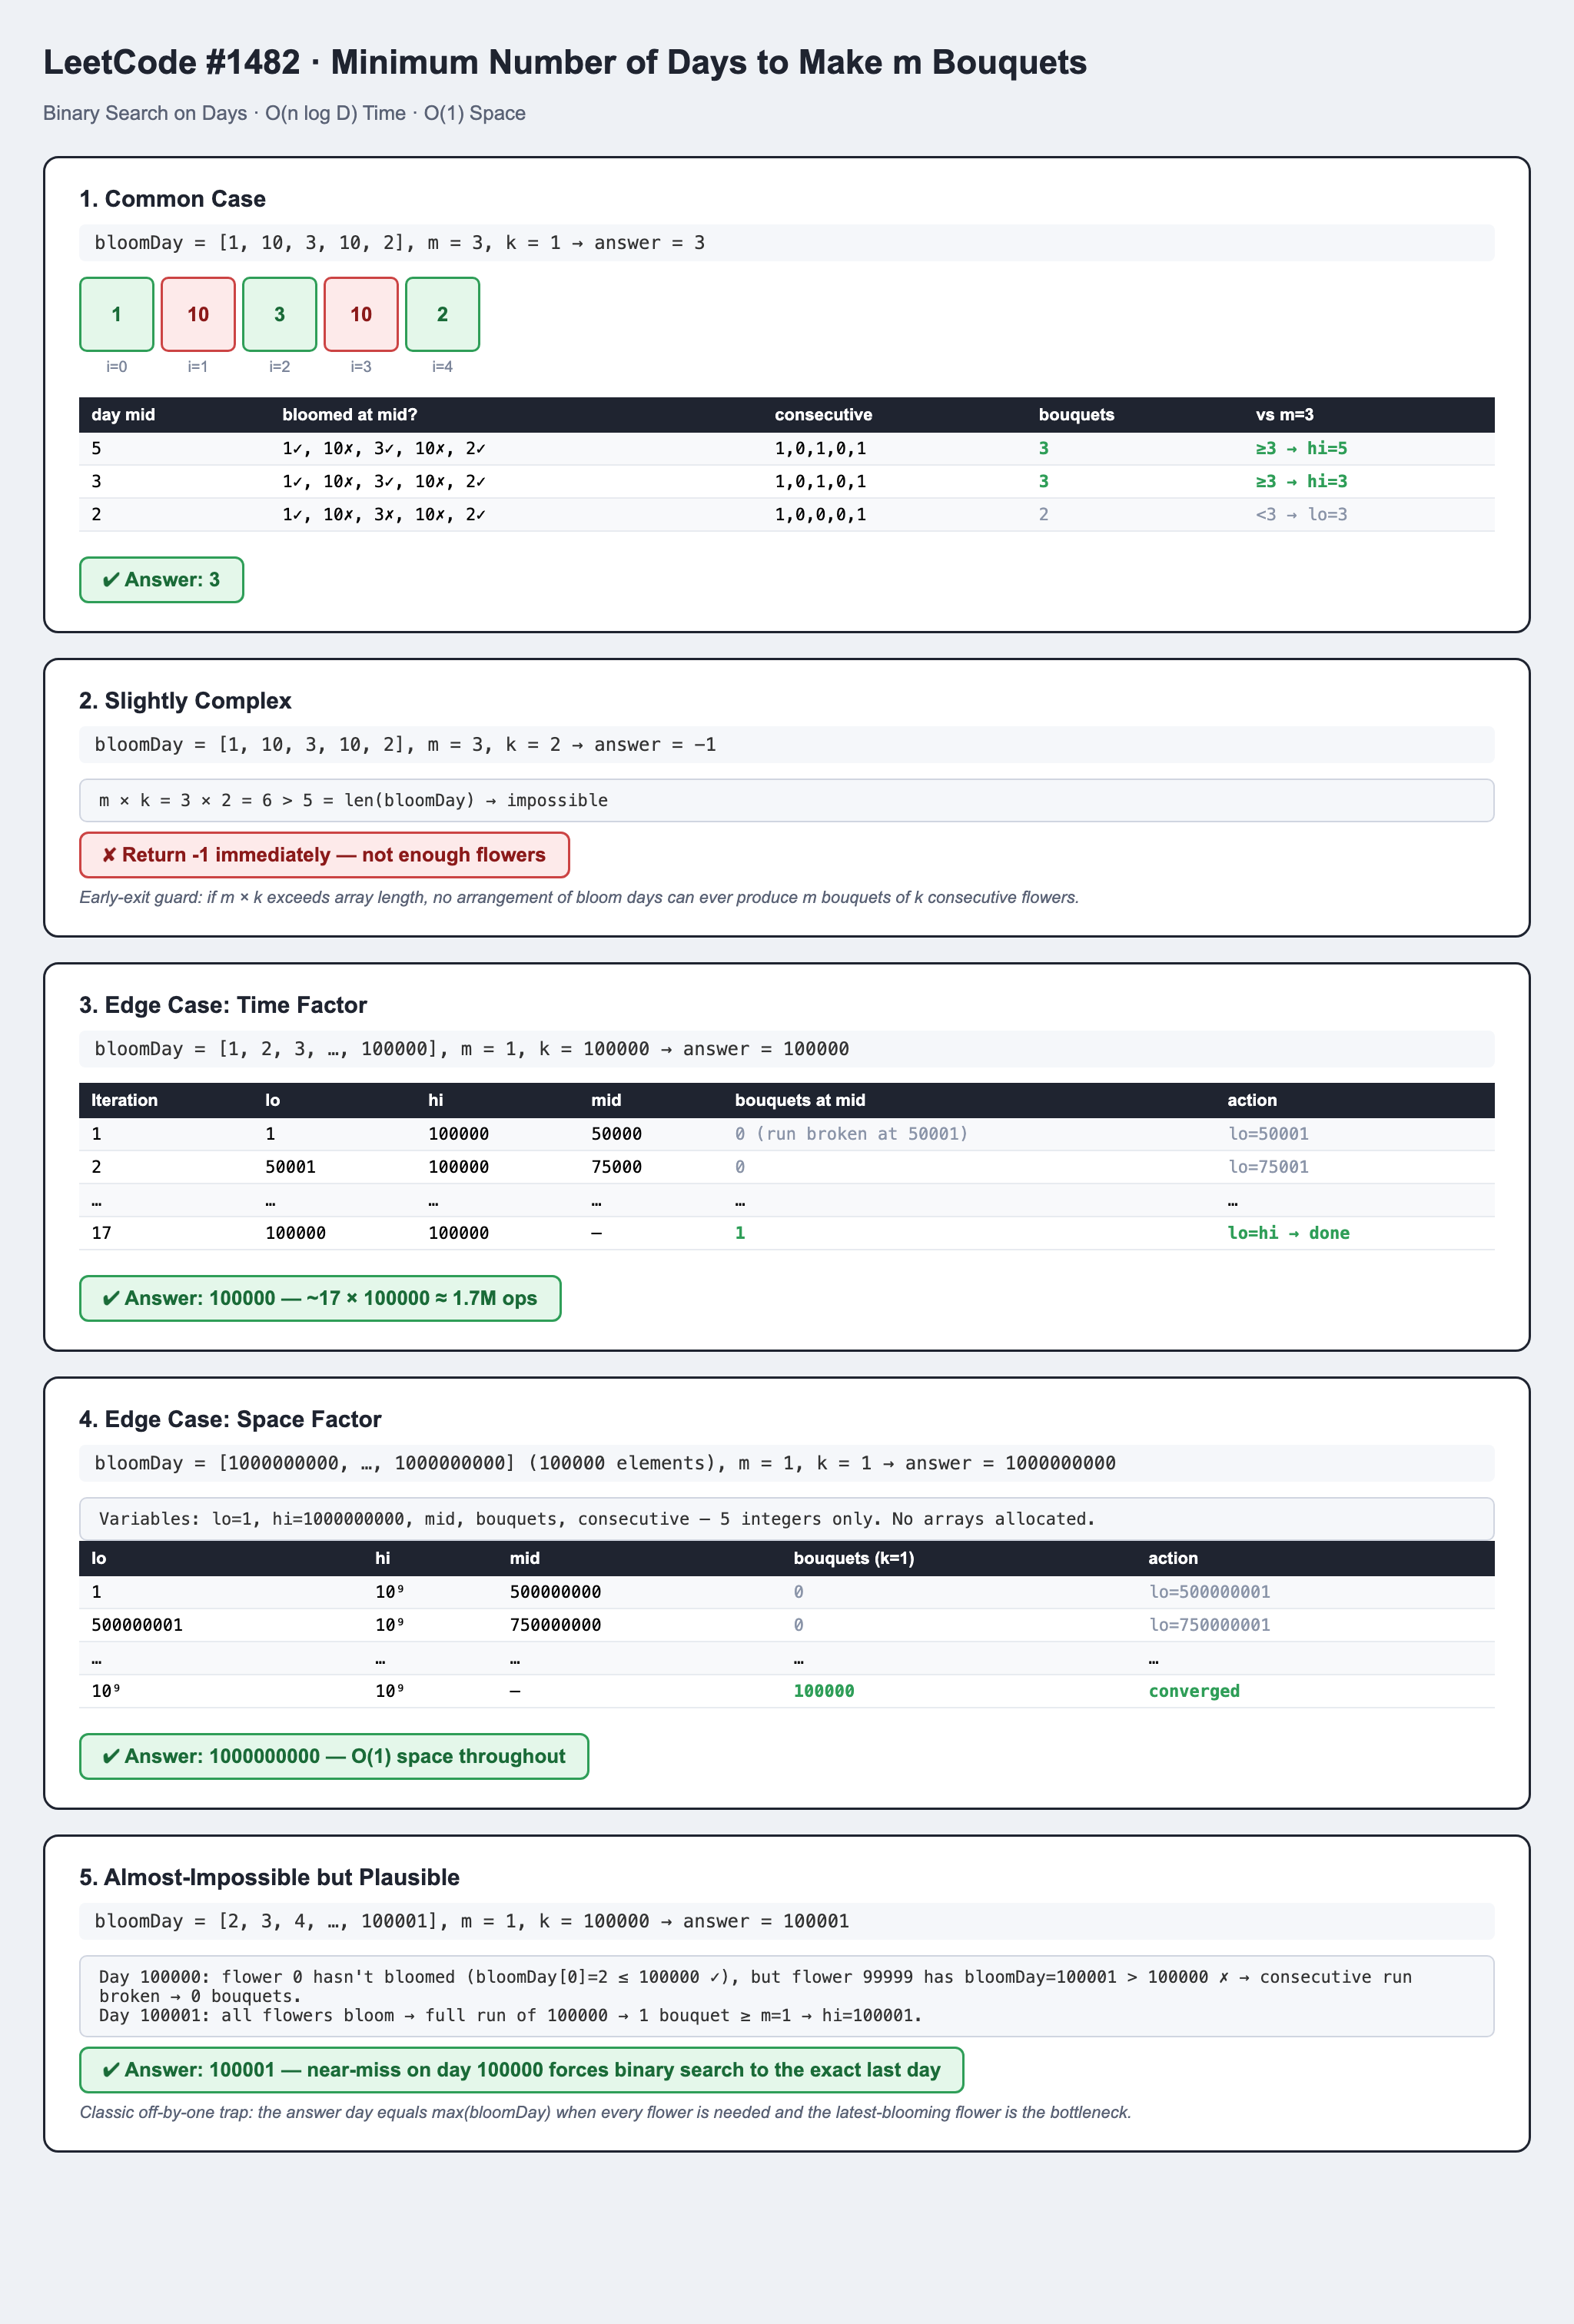